# Masked Diffusion Language Models (MDLM)

**Goal**: Sample from a distribution $p_\text{data}(x)$ over *discrete* sequences $x \in \{1, \ldots, V\}^L$ (tokens, categories, quantised pixels).
Because of the discrete tokens, gradual disturbance with Gaussian noise (as in DDPMs) does not work.

**Idea**: Gradually erase data by replacing individual tokens with a special `[MASK]` token.
Use a model to learn the reverse: predict the original tokens at masked positions from context at various levels of masking. Generate by starting from an all-masked sequence and unmask in steps (but in parallel) until nothing is masked.

## Forward and Reverse Process

**Forward (noising)**:
Design masking so that each position's mask time is uniform on $[0, 1]$. Then
time controls how much of the sequence has been erased.
- $t = 0$: clean sample
- $t = 1$: every position is `[MASK]`
- Intermediate $t$: each position independently masked with probability $t$, expected number of mask tokens is $t\cdot L$ for sequence length $L$.

**Role of the model**: Predict $p_\theta(x_0[i] \mid x_t)$ — a categorical distribution over the *original* tokens at each position,
given the partially-masked context.
One forward pass gives predictions for all positions in parallel (BERT-style).
Training loss is cross-entropy on the predicted tokens at masked positions, weighted by $1/t$.

**Reverse (sampling)**: Discretise time into $1 = t_N > \cdots > t_0 = 0$, start from fully masked sequence, and step down.
 At each step an expected fraction $(t_n - t_{n-1})/t_n$ of the still-masked positions is demasked with a token sampled from $p_\theta$.
The expected number of remaining masks after step $n$ is $t_n\cdot L$,
matching the forward process. Masks dwindle from $L$ to $0$ over $N$ steps.




## Why does this work?
As usual, $p_{\theta}(x)$ is hard to fit, because of the high number of possible sequences.
With the forward process that progressively masks tokens,
a network to predict masked tokens from context, and a sampler that
unmasks step by step, a process to sample from an approximate distribution is defined. It can be shown
that this is an an ELBO approximation of the data distribution.

**The ELBO in the context of masked diffusion**
Generally an ELBO is a tractable expression that lower-bounds
$\log p_\theta(x_0)$; you maximise it to maximise the log likelihood of the data sample.
To get a useful one for sampling introduce a convenient latent variable to define $p(x,y)$, $p(x|y)$. Then,
pick an auxiliary distribution $q$ over latent variables that you can sample
from. Bound the log-likelihood (which is a marginal over $y$) of the data by an expectation under $q$, which needs to be
something tractable to optimize during training. For diffusion models, $q$ is the distribution resulting from the forward (noising or
masking) process, tractable by construction, and the latent variables are the
intermediate masked series.

Applying this method to the forward process and taking the
continuous-time limit, the bound can be shown to be:

$$
-\log p_\theta(x_0) \;\le\; \mathbb{E}_{t,\, x_t \mid x_0}\!
\left[\frac{1}{t}\sum_{i:\,x_t^i=\texttt{[MASK]}}
-\log p_\theta(x_0^i \mid x_t)\right],
\qquad t \sim U[0,1].
$$

Two things fall out:
- a loss to optimize: we can use the cross-entropy on masked positions.
- the $1/t$ weight: it balances the contribution of each
mask rate (heavily-masked examples contribute many terms,
lightly-masked few).

**Difference to BERT?** BERT trains the same cross-entropy at masked positions, but with $t$ fixed.
That makes BERT's loss a representation-learning objective, but not a bound on log likelihood of the data distribution.

**Difference to AR models?** The MDLM loss trains
 a single network to predict tokens in every possible order.
An AR model trains only left-to-right ordering. This
is why MDLM-class models handle infilling and reversal tasks better.

**Why not condition on timesteps in the model?** In Gaussian diffusion the network must know
$t$ to gauge the noise scale. Here $x_t$ carries that information: the number of masks
implies $t$. Different times with the same $x_t$ have the same
optimal prediction.

**Doesn't parallel independent unmasking lead to errors?** Yes.
This is one main trade-off in the model:
generate more tokens in parallel vs. risk of generating
inconsistent tokens in a step.
Some practical methods to address this: small steps,
"low-confidence remasking" (committing only the most confident predictions per step),
 or ReMDM (allowing already-committed tokens to be re-masked and revised in later steps).

## Training and Sampling

### Training

For one training step:

1. Sample $x_0 \sim p_\text{data}$ and $t \sim \text{Uniform}(0, 1)$
2. Mask each position of $x_0$ independently with probability $t$ to form $x_t$
3. **Input to network**: $x_t$ alone (no time $t$ explicitly needed)
4. **Output**: per-position logits over the vocabulary $\{1, \ldots, V\}$
5. **Target**: the original token $x_0[i]$ at every masked position
6. **Loss**: cross-entropy at masked positions only, weighted by $1/t$:

$$\mathcal{L} = \mathbb{E}_{t,\, x_0,\, x_t}\!\left[\frac{1}{t} \sum_{i:\, x_t[i]=\text{MASK}} -\log p_\theta(x_0[i] \mid x_t)\right]$$

The network never sees $x_0$ — only the partially-masked $x_t$. It reconstructs masked positions from bidirectional context. Unmasked positions don't contribute. The $1/t$ weight comes straight from the ELBO: few positions are masked at small $t$, so the summed CE is small per sample; $1/t$
 rescales so each mask fraction contributes equally in expectation.

### Sampling

Start from $x_1 = [\text{MASK}, \ldots, \text{MASK}]$ and step down through $1 = t_N > t_{N-1} > \cdots > t_0 = 0$. At each step:

1. Run the network on $x_{t_n}$ to get per-position categorical distributions
2. For each currently-masked position, independently decide whether to unmask — probability $(t_n - t_{n-1})/t_n$ (reverse posterior for absorbing noise)
3. If unmasking: sample the revealed token from $p_\theta(\cdot \mid x_{t_n})[i]$

Every step reveals ${\sim}L/N$ tokens *in parallel*. The network sees full bidirectional context — unlike autoregressive generation, which generates tokens left-to-right.

### References

- **Sahoo et al. (2024)** — [Simple and Effective Masked Diffusion Language Models](https://arxiv.org/abs/2406.07524). ELBO derivation; demonstrates that this recipe matches or beats SEDD at scale.
- **Shi et al. (2024)** — [Simplified and Generalized Masked Diffusion for Discrete Data](https://arxiv.org/abs/2406.04329). Continuous-time absorbing-state ELBO with schedule-invariant form.
- **Nie et al. (2025)** — [Large Language Diffusion Models (LLaDA)](https://arxiv.org/abs/2502.09992). 8B-parameter MDLM trained from scratch; competitive with LLaMA-3 8B.

In [1]:
import jax
import jax.numpy as jnp
from jax import random, jit
import flax.linen as nn
import optax
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

np.random.seed(0)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

key = random.PRNGKey(42)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
print('JAX:', jax.__version__, '| devices:', jax.devices())

JAX: 0.9.2 | devices: [CudaDevice(id=0)]


## Toy Dataset — Length-16 Simple Polygons

Each sample is a 16-step walk on an integer lattice that traces a polygon: starts and ends at the origin and visits 16 distinct vertices,
 so there is no line crossing. Think of a pen drawing while following directions.
 Vocabulary: four direction tokens $\{\uparrow, \rightarrow, \downarrow, \leftarrow\}$ encoded as $\{0, 1, 2, 3\}$ plus an absorbing `[MASK] = 4`.

The data distribution is built by enumeration: a DFS with Manhattan-distance pruning produces every length-16 simple polygon starting at the origin. Training samples are drawn uniformly from this set.
There are two classes of polygons - sequences going clockwise and counterclockwise.

In [2]:
# ---- Data: simple-polygon walks of length L on Z^2 ----
L = 16                                              # sequence length
N_DIRS = 4                                          # U=0, R=1, D=2, L=3
MASK = 4
VOCAB = 5                                           # 4 directions + MASK
DIRS = jnp.array([[ 0,  1],                         # U  (dx=0,  dy=+1)
                  [ 1,  0],                         # R  (dx=+1, dy=0)
                  [ 0, -1],                         # D
                  [-1,  0]])                        # L
DIR_GLYPH = ['↑', '→', '↓', '←']
N_TRAIN = 4096
N_TEST = 1024

In [3]:
import sys, time
sys.setrecursionlimit(10000)
_DIRS_T = [(0, 1), (1, 0), (0, -1), (-1, 0)]    # matches DIRS above

def enumerate_simple_polygons(length):
    """All length-`length` simple-polygon token sequences starting at origin.
    DFS with Manhattan-distance pruning.
    """
    polygons = []
    seq      = []

    def dfs(x, y, visited):
        k = len(seq)
        if k == length:
            if x == 0 and y == 0:
                polygons.append(tuple(seq))
            return
        remaining = length - k
        if abs(x) + abs(y) > remaining:
            return
        for d, (dx, dy) in enumerate(_DIRS_T):
            nx, ny = x + dx, y + dy
            revisits = (nx, ny) in visited
            if revisits and not (nx == 0 and ny == 0 and k == length - 1):
                continue
            seq.append(d)
            if not revisits:
                visited.add((nx, ny))
            dfs(nx, ny, visited)
            seq.pop()
            if not revisits:
                visited.remove((nx, ny))

    dfs(0, 0, {(0, 0)})
    return polygons


def _signed_area_of_tokens(tokens):
    """Shoelace on the walk traced by `tokens` (closed walk assumed). +CCW, -CW."""
    x = y = 0
    area = 0
    for t in tokens:
        dx, dy = _DIRS_T[t]
        nx, ny = x + dx, y + dy
        area += x * ny - nx * y
        x, y = nx, ny
    return area


t0 = time.time()
ALL_POLYGONS  = [np.array(p, dtype=np.int32) for p in enumerate_simple_polygons(L)]
ALL_CHIRALITY = np.array([0 if _signed_area_of_tokens(p) < 0 else 1
                          for p in ALL_POLYGONS], dtype=np.int32)
# 0 = CW (negative signed area), 1 = CCW (positive signed area)
print(f'Enumerated {len(ALL_POLYGONS):,} length-{L} simple polygons in {time.time() - t0:.1f}s')
print(f'  CW:  {(ALL_CHIRALITY == 0).sum():,}    CCW: {(ALL_CHIRALITY == 1).sum():,}')


def sample_dataset(n_train, n_test):
    """Uniform sampling from the enumerated polygon library with chirality labels."""
    perm = np.random.permutation(len(ALL_POLYGONS))
    idx_train, idx_test = perm[0:n_train], perm[n_train:n_train + n_test]
    X_train = np.stack([ALL_POLYGONS[i] for i in idx_train])
    y_train = ALL_CHIRALITY[idx_train]
    X_test = np.stack([ALL_POLYGONS[i] for i in idx_test])
    y_test = ALL_CHIRALITY[idx_train]
    return X_train, y_train, X_test, y_test



x_train, y_train, x_test, y_test = sample_dataset(N_TRAIN, N_TEST)
print(f'Sampled training set: {x_train.shape}   tokens present: {np.unique(x_train)} tokens present: {np.unique(x_test)}')
print(f'Test set {x_test.shape} ')

Enumerated 94,016 length-16 simple polygons in 0.6s
  CW:  47,008    CCW: 47,008
Sampled training set: (4096, 16)   tokens present: [0 1 2 3] tokens present: [0 1 2 3]
Test set (1024, 16) 


### Validity and rendering helpers

A sample is a *simple polygon* if it (i) returns to the origin, (ii) visits 16 distinct grid cells in total (start + 16 steps, start = end).

`draw_walk` renders a sequence as a polyline: solid segments coloured by direction along the walk, with masked positions marked by a red dot at the current position (a MASK contributes zero displacement). Movement direction is encoded starting from light towards dark colors.

`draw_token_strip` shows the per-position token row.

In [4]:
# ---- Display ----
GRID_HALF   = 7                                      # any length-16 simple polygon fits
DIR_COLORS  = ['tab:red', 'tab:blue', 'tab:green', 'tab:purple']    # U, R, D, L (token strip only)
MASK_COLOR  = 'lightgray'
TOKEN_COLORS = DIR_COLORS + [MASK_COLOR]
WALK_CMAP   = plt.cm.viridis_r                         # along-walk colour for renderings
VALID_COLOR = 'tab:green'
INVALID_COLOR = 'tab:red'

Validity on 500 training samples: {'CW': 220, 'CCW': 280, 'invalid': 0}


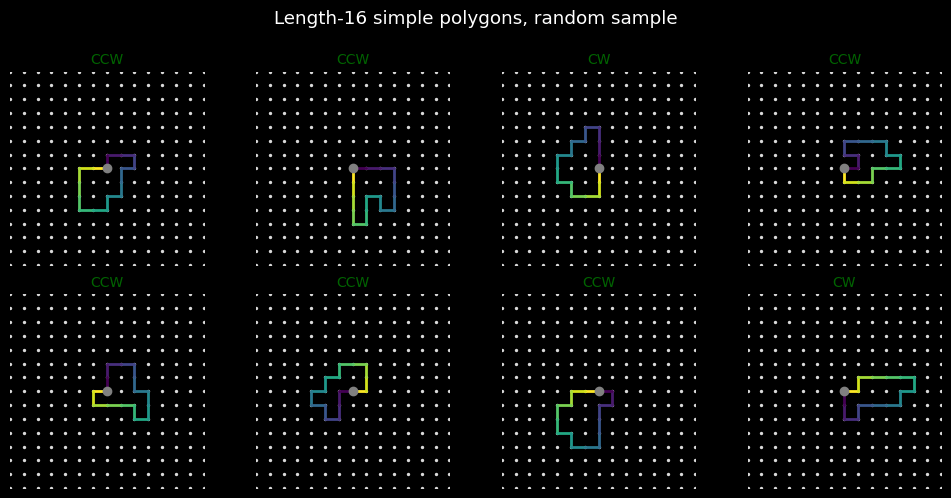

In [5]:
def walk_positions(seq):
    """Cumulative grid positions for token sequence. MASK contributes zero displacement."""
    seq = np.asarray(seq)
    disp = np.zeros((len(seq), 2), dtype=np.int32)
    not_masked = seq < N_DIRS
    disp[not_masked] = np.array(DIRS)[seq[not_masked]]
    pos = np.zeros((len(seq) + 1, 2), dtype=np.int32)
    pos[1:] = np.cumsum(disp, axis=0)
    return pos


def is_simple_polygon(seq):
    """Closed + non-self-intersecting + non-zero area.
    For axis-aligned unit walks: simplicity <=> all L vertices distinct.
    returns is simple polygon, direction (counterclockwise or clockwise)
    """
    if np.any(np.asarray(seq) >= N_DIRS):
        return False, None
    pos = walk_positions(seq)
    if not np.array_equal(pos[0], pos[L]):
        return False, None
    if len({tuple(p) for p in pos[:L]}) != L:
        return False, None
    area = 0.0
    for i in range(L):
        area += pos[i, 0] * pos[i + 1, 1] - pos[i + 1, 0] * pos[i, 1]
    if area > 0: return True, 'CCW'
    if area < 0: return True, 'CW'
    return False, None


def _draw_grid_dots(ax):
    """Faint integer-lattice dots in the display window."""
    rng_xy = range(-GRID_HALF, GRID_HALF + 1)
    xs, ys = np.meshgrid(rng_xy, rng_xy)
    ax.scatter(xs.ravel(), ys.ravel(), s=2, color='#d9d9d9', zorder=0)


def draw_walk(ax, seq, solid_color=None, mark_endpoints=True, lw=2.0):
    """Render a token sequence as a polyline.

    solid_color=None: segments coloured by their index along the walk (viridis).
    solid_color set:  every unmasked segment uses that colour.
    Masked positions are marked with a red dot at the current pen position.
    """
    seq = np.asarray(seq)
    pos = walk_positions(seq)
    n   = len(seq)
    for i, tok in enumerate(seq):
        x0, y0 = pos[i]; x1, y1 = pos[i + 1]
        if tok == MASK:
            ax.plot(x0, y0, 'o', color='tab:red', ms=4, zorder=4)
        else:
            colour = solid_color if solid_color else WALK_CMAP(i / max(n - 1, 1))
            ax.plot([x0, x1], [y0, y1], color=colour, lw=lw,
                    solid_capstyle='round')
    if mark_endpoints:
        ax.plot(pos[0, 0], pos[0, 1], 'o', color='gray', ms=6, zorder=5)
        if not np.array_equal(pos[0], pos[n]):
            ax.plot(pos[n, 0], pos[n, 1], 's', mfc='none', mec='gray',
                    ms=7, mew=1.2, zorder=5)
    _draw_grid_dots(ax)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xlim(-GRID_HALF, GRID_HALF); ax.set_ylim(-GRID_HALF, GRID_HALF)
    ax.set_aspect('equal')


def draw_token_strip(ax, seq, fontsize=8):
    """1xL row of coloured cells, one per sequence position."""
    seq = np.asarray(seq)
    for i, tok in enumerate(seq):
        col   = TOKEN_COLORS[tok]
        glyph = '?' if tok == MASK else DIR_GLYPH[tok]
        text_col = 'dimgrey' if tok == MASK else 'white'
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=col,
                                   edgecolor='white', lw=1))
        ax.text(i + 0.5, 0.5, glyph, ha='center', va='center',
                fontsize=fontsize, color=text_col)
    ax.set_xlim(0, len(seq)); ax.set_ylim(0, 1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')


# Sanity: training samples should all be simple polygons (the enumerator only outputs them)
val_counts = {'CW': 0, 'CCW': 0, 'invalid': 0}
for s in x_train[:500]:
    ok, ch = is_simple_polygon(s)
    val_counts[ch if ok else 'invalid'] += 1
print(f'Validity on 500 training samples: {val_counts}')

# Dataset gallery: random walks coloured along their length
gallery_i = np.random.choice(len(x_train), size=8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, idx in zip(axes.flat, gallery_i):
    seq = x_train[idx]
    draw_walk(ax, seq)
    _, ch = is_simple_polygon(seq)
    ax.set_title(ch, fontsize=10, color='darkgreen')
plt.suptitle(f'Length-{L} simple polygons, random sample', y=0.99)
plt.tight_layout(); plt.show()

## Forward Masking

At time $t \in [0, 1]$ each position is independently replaced by `[MASK]` with probability $t$:

$$q(x_t[i] = \text{MASK} \mid x_0[i]) = t, \qquad q(x_t[i] = x_0[i] \mid x_0[i]) = 1 - t.$$

Visualised on a walk: as $t$ rises the drawing pen "misses" more of its instructions (no movement, marked by red dots).

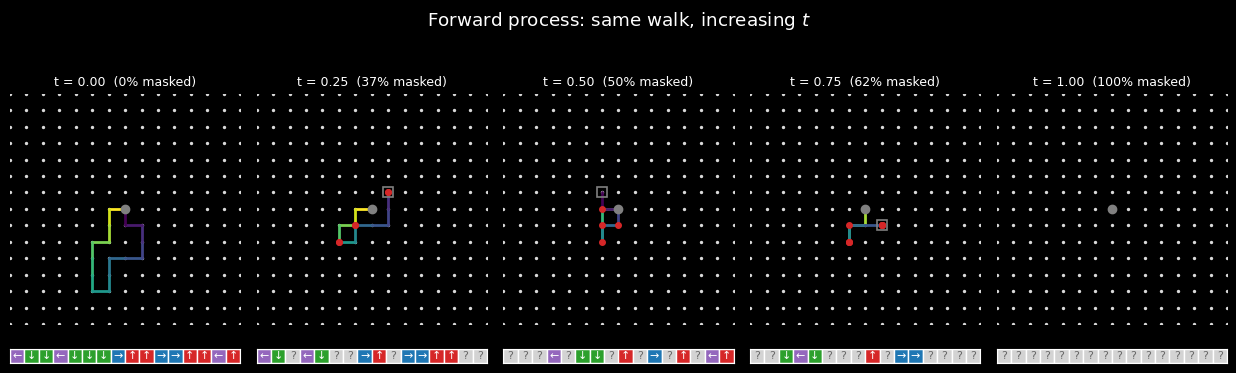

In [6]:
def q_sample(x0, t, key):
    """Mask each position of x0 independently with probability t."""
    is_masked = random.bernoulli(key, t, shape=x0.shape)
    return jnp.where(is_masked, MASK, x0)

# Visualise: same walk at increasing t, walk on top + token strip below
show_ts = [0.0, 0.25, 0.5, 0.75, 1.0]
ref_idx = np.where(y_train == 1)[0][0]                  # a CCW example
x0_ref  = jnp.array(x_train[ref_idx])

fig, axes = plt.subplots(2, len(show_ts),
                         figsize=(2.5 * len(show_ts), 4),
                         gridspec_kw={'height_ratios': [3, 1]})
key, *sks = random.split(key, len(show_ts) + 1)
for col, (t_val, sk) in enumerate(zip(show_ts, sks)):
    x_t = q_sample(x0_ref, t_val, sk)
    percentage = int(100 * float(jnp.mean(x_t == MASK)))
    draw_walk(axes[0, col], x_t)
    axes[0, col].set_title(f't = {t_val:.2f}  ({percentage}% masked)', fontsize=9)
    draw_token_strip(axes[1, col], x_t)
plt.suptitle('Forward process: same walk, increasing $t$', y=1.02)
plt.tight_layout(); plt.show()

## Training Task

For each training step: sample $x_0$, sample $t \sim U[0,1]$, mask each position independently with probability $t$ to form $x_t$, predict the original direction token at every masked position. Loss is cross-entropy at masked positions weighted by $1/t$.

The figure below shows two random polygons at one $t$ each: input $x_t$ (left) and target $x_0$ (right). The model has to fill in directions to replace the red dots with the original line segments, using the rest of the directions as context.

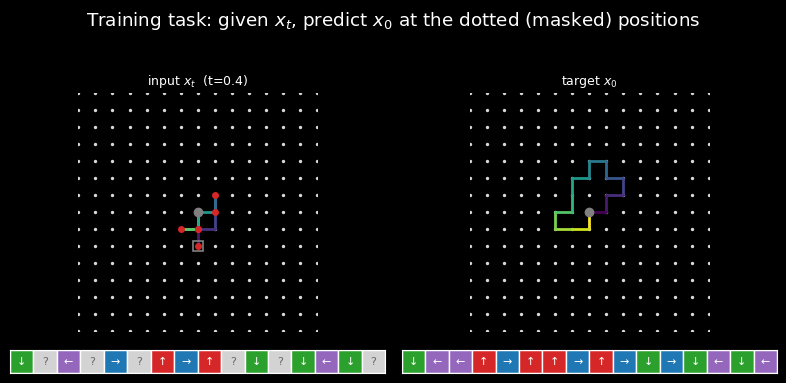

In [7]:
key, sk_t, sk_idx = random.split(key, 3)
task_t   = 0.4
task_idx = int(random.randint(sk_idx, (), 0, x_train.shape[0]))

x0_show = jnp.array(x_train[task_idx])
x_t = q_sample(x0_show, task_t, sk_t)

fig, axes = plt.subplots(2, 2, figsize=(8, 4), gridspec_kw={'height_ratios': [3, 1]})
# input
draw_walk(axes[0, 0], x_t)
axes[0, 0].set_title(f'input $x_t$  (t={task_t})', fontsize=9)
draw_token_strip(axes[1, 0], x_t)
# target
draw_walk(axes[0, 1], x0_show)
axes[0, 1].set_title('target $x_0$', fontsize=9)
draw_token_strip(axes[1, 1], x0_show)

plt.suptitle('Training task: given $x_t$, predict $x_0$ at the dotted (masked) positions', y=1.02)
plt.tight_layout(); plt.show()

## Model — A Small Transformer

The denoiser reads the full sequence and predicts a categorical distribution over the four directions at every position:

- **Token embedding**: learned, 5 entries for $\{0, 1, 2, 3, \text{MASK}\}$
- **Position embedding**: learned ($L=16$)
- **Body**: 2 pre-norm Transformer blocks, 4 heads, MLP hidden 128
- **Head**: linear projection to 4 logits per position (MASK is never a prediction target)

No time embedding: $x_t$ alone is enough — the count and pattern of `[MASK]` tokens already encode how much context is present.

Self-attention on the sequence of tokens may learn to reflect global sequence properties like shape and chirality.

In [8]:
# ---- Model ----
MODEL_DIM     = 64
MODEL_N_HEADS = 4
MODEL_N_LAYERS = 2
MODEL_MLP_DIM = 128


In [9]:
class TransformerBlock(nn.Module):
    dim:     int = 64
    n_heads: int = 4
    mlp_dim: int = 128

    @nn.compact
    def __call__(self, x):
        h = nn.LayerNorm()(x)
        h = nn.MultiHeadDotProductAttention(num_heads=self.n_heads)(h, h) # self attention: Key=h, Query and Value=h
        x = x + h
        h = nn.LayerNorm()(x)
        h = nn.Dense(self.mlp_dim)(h)
        h = nn.gelu(h)
        h = nn.Dense(self.dim)(h)
        return x + h


class MaskedDenoiser(nn.Module):
    """Given x_t in {0,..,N_DIRS-1, MASK}^L, predict logits over directions per position."""
    dim:      int = 64
    n_heads:  int = 4
    n_layers: int = 2
    mlp_dim:  int = 128

    @nn.compact
    def __call__(self, x_t): #  xt: shape (batch, L)
        tok_emb = nn.Embed(VOCAB, self.dim)(x_t)
        pos_ids = jnp.arange(L)[None, :] # shape (1, L)
        pos_emb = nn.Embed(L, self.dim)(pos_ids)
        h = tok_emb + pos_emb
        for _ in range(self.n_layers):
            h = TransformerBlock(self.dim, self.n_heads, self.mlp_dim)(h)
        h = nn.LayerNorm()(h)
        return nn.Dense(N_DIRS)(h)


model = MaskedDenoiser(dim=MODEL_DIM, n_heads=MODEL_N_HEADS,
                       n_layers=MODEL_N_LAYERS, mlp_dim=MODEL_MLP_DIM)
key, sk = random.split(key)
params = model.init(sk, jnp.zeros((4, L), dtype=jnp.int32))
n_p = sum(leaf.size for leaf in jax.tree_util.tree_leaves(params))
print(f'Parameters: {n_p:,}')

Parameters: 68,676


## Training

$$\mathcal{L} = \mathbb{E}_{t \sim U[0,1],\, x_0,\, x_t}\!\left[\frac{1}{t} \sum_{i:\, x_t[i]=\text{MASK}} -\log p_\theta(x_0[i] \mid x_t)\right]$$

Numerical note: clip $t$ away from $0$ so the $1/t$ weight does not blow up.

Even for a large number of epochs the model does not overfit:
In each epoch, the sequences are masked with random t, an implicit data augmentation. Additionally, for a given masked $x_t$, there is in general no single solution $x_0$.

In [10]:
# ---- Training ----
N_EPOCHS      = 10_000
BATCH_SIZE    = 256
LR            = 3e-4
EPS_T         = 1e-3
LOSS_SMOOTH_W = 40

Epoch    0  loss = 26.3381, val_loss = 22.9609
Epoch 1250  loss = 13.8771, val_loss = 12.9766
Epoch 2500  loss = 12.9043, val_loss = 13.0237
Epoch 3750  loss = 12.3105, val_loss = 12.3941
Epoch 5000  loss = 12.4258, val_loss = 12.1701
Epoch 6250  loss = 12.5447, val_loss = 12.9088
Epoch 7500  loss = 12.6454, val_loss = 12.7256
Epoch 8750  loss = 11.6980, val_loss = 12.0442


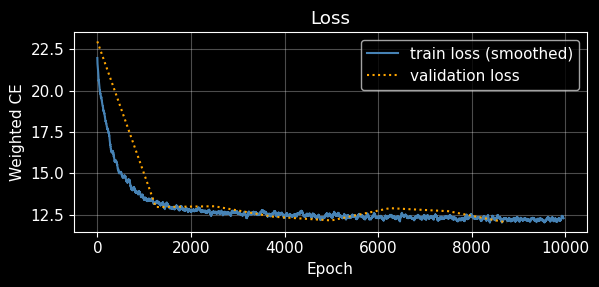

In [11]:
optimizer = optax.adam(LR)
opt_state = optimizer.init(params)


def masked_diffusion_loss(params, x0_batch, key):
  k1, k2 = random.split(key)
  B = x0_batch.shape[0]
  t = random.uniform(k1, (B,), minval=EPS_T, maxval=1.0)
  is_masked = random.uniform(k2, (B, L)) < t[:, None]
  x_t = jnp.where(is_masked, MASK, x0_batch)

  logits = model.apply(params, x_t)
  ce = optax.softmax_cross_entropy_with_integer_labels(logits, x0_batch)
  per_sample = jnp.sum(ce * is_masked.astype(jnp.float32), axis=-1) / t
  return jnp.mean(per_sample)


@jit
def train_step(params, opt_state, x0_batch, key):
  loss, grads = jax.value_and_grad(masked_diffusion_loss)(params, x0_batch, key)
  updates, new_opt = optimizer.update(grads, opt_state)
  return optax.apply_updates(params, updates), new_opt, loss


eval_step = jit(masked_diffusion_loss)

losses = []
val_losses = []
val_epochs = []

for epoch in range(N_EPOCHS):
    key, sk1, sk2 = random.split(key, 3)
    idx   = random.randint(sk1, (BATCH_SIZE,), 0, len(x_train))
    batch = jnp.array(x_train[idx])
    params, opt_state, loss_val = train_step(params, opt_state, batch, sk2)
    losses.append(float(loss_val))
    if epoch % max(1, N_EPOCHS // 8) == 0:
        val_loss = eval_step(params, x_test, key)
        val_losses.append(float(val_loss))
        val_epochs.append(epoch)
        print(f'Epoch {epoch:4d}  loss = {loss_val:.4f}, val_loss = {val_loss:.4f}')

params_full = params                                       # save for reuse later

w_smooth = min(LOSS_SMOOTH_W, max(1, len(losses) // 4))
smoothed = np.convolve(losses, np.ones(w_smooth) / w_smooth, mode='valid')
plt.figure(figsize=(6, 3))
plt.plot(smoothed, lw=1.5, c='steelblue', label='train loss (smoothed)')
plt.plot(val_epochs, val_losses, c='orange', label='validation loss', linestyle=':')
plt.xlabel('Epoch')
plt.ylabel('Weighted CE')
plt.title(f'Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Sampling — Iterative Unmasking

Start from $x_1 = [\text{MASK}]^L$ and step down through $1 = t_N > t_{N-1} > \cdots > t_0 = 0$. At each step, for every currently-masked position $i$, independently:

$$\text{unmask rate} = \frac{t_n - t_{n-1}}{t_n}$$

If the decision is to unmask, sample the revealed token from $p_\theta(\cdot \mid x_{t_n})[i]$.

Two nice properties:

- After $n$ steps the expected fraction of remaining masks is $t_n$ — the reverse matches the forward process
- The decision for every position in parallel at each step

In [22]:
# ---- Sampling ----
N_SAMPLING_STEPS  = 16
N_DISPLAY_SAMPLES = 12
STEPS_COMPARE     = [1, 2, 4, 8, 16, 32]
EVAL_N_SAMPLES    = 500

Valid simple-polygon rate (displayed): 8/12


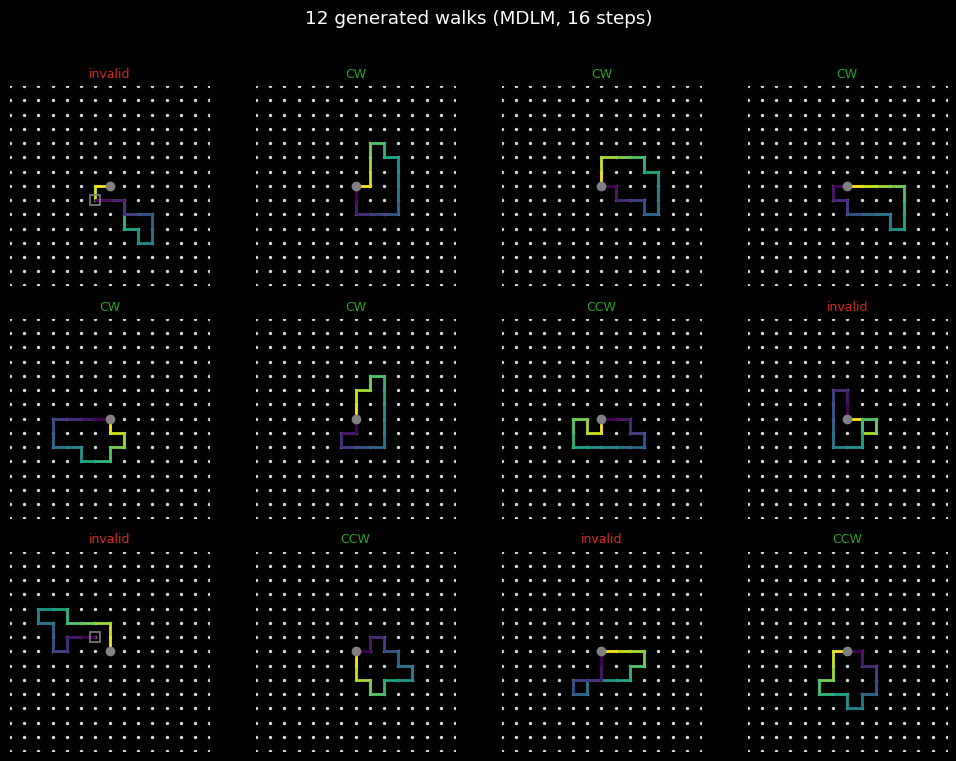

In [24]:
@jit
def predict_logits(params, x_t):
    return model.apply(params, x_t) # (Batchsize, Len Sequence, num Tokens)


def sample(params, key, n_samples=16, n_steps=16, save_trajectory=False):
    """Sampling: start from all-MASK, iteratively unmask.
    Returns final x_t and (optionally) a list with the state after every step.
    """
    x_t = jnp.full((n_samples, L), MASK, dtype=jnp.int32)
    ts = jnp.linspace(1.0, 0.0, n_steps + 1)
    traj = [np.array(x_t)] if save_trajectory else None
    for k in range(n_steps):
        t_now, t_next = float(ts[k]), float(ts[k + 1])
        unmask_rate = (t_now - t_next) / max(t_now, 1e-8)
        key, k1, k2 = random.split(key, 3)
        logits  = predict_logits(params, x_t)
        do_unmask = (random.uniform(k1, (n_samples, L)) < unmask_rate) & (x_t == MASK)
        sampled   = random.categorical(k2, logits, axis=-1)
        x_t = jnp.where(do_unmask, sampled, x_t)
        if save_trajectory:
            traj.append(np.array(x_t))
    return x_t, traj


key, sk = random.split(key)
samples, _ = sample(params_full, sk, n_samples=N_DISPLAY_SAMPLES,
                    n_steps=N_SAMPLING_STEPS)
samples_np = np.array(samples)

# Validity + chirality on the displayed batch
verdicts = [is_simple_polygon(s) for s in samples_np]
n_valid  = sum(int(v[0]) for v in verdicts)
print(f'Valid simple-polygon rate (displayed): {n_valid}/{N_DISPLAY_SAMPLES}')

ncols = 4
nrows = N_DISPLAY_SAMPLES // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 2.5 * nrows))
for ax, trajectory, (ok, ch) in zip(axes.flat, samples_np, verdicts):
    draw_walk(ax, trajectory)
    label, col = (ch, 'tab:green') if ok else ('invalid', 'tab:red')
    ax.set_title(label, fontsize=9, color=col)
plt.suptitle(f'{N_DISPLAY_SAMPLES} generated walks (MDLM, {N_SAMPLING_STEPS} steps)', y=1.01)
plt.tight_layout(); plt.show()

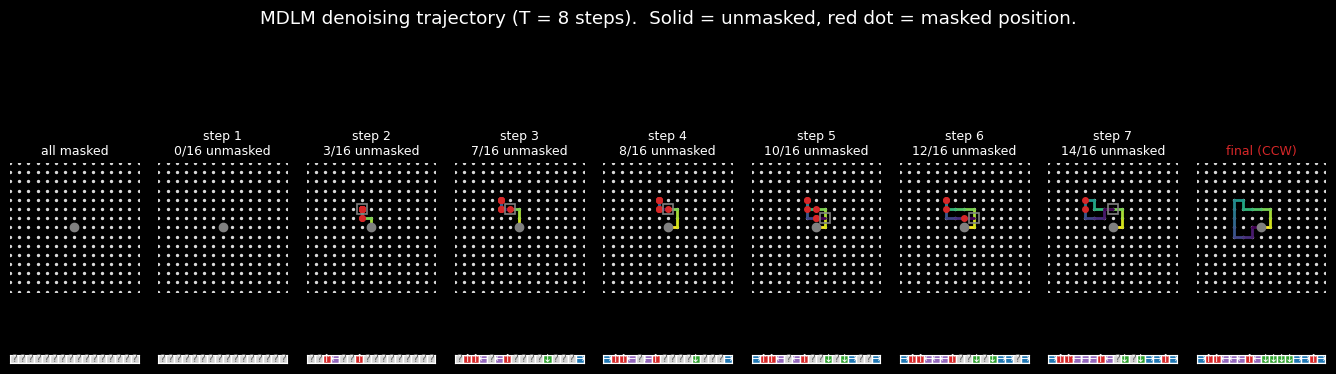

In [28]:
# visualize per-step unmasking
TRAJ_STEPS = 8

key, sk = random.split(key)
_, traj = sample(params_full, sk, n_samples=1, n_steps=TRAJ_STEPS,
                 save_trajectory=True)
traj_seqs = [t[0] for t in traj]                       # flatten each item to get list of (L,) sequences

final = traj_seqs[-1]
is_ok, chirality = is_simple_polygon(final)
final_label = chirality if is_ok else 'invalid'

n_cols = len(traj_seqs)
fig, axes = plt.subplots(2, n_cols, figsize=(1.5 * n_cols, 4), gridspec_kw={'height_ratios': [3, 1]})

for col, seq in enumerate(traj_seqs):
    n_mask = int(np.sum(seq == MASK))
    draw_walk(       axes[0, col], seq)
    draw_token_strip(axes[1, col], seq)
    if col == 0:
        axes[0, col].set_title('all masked', fontsize=9)
    elif col == n_cols - 1:
        axes[0, col].set_title(f'final ({final_label})', fontsize=9,
                               color='tab:green' if ok else 'tab:red')
    else:
        axes[0, col].set_title(f'step {col}\n{L - n_mask}/{L} unmasked', fontsize=9)
plt.suptitle(f'MDLM denoising trajectory (T = {TRAJ_STEPS} steps).  '
             f'Solid = unmasked, red dot = masked position.', y=1.04)
plt.tight_layout(); plt.show()

## Sampling Quality vs. Number of Steps

$N$ trades quality for cost. At $N = 1$ all positions are unmasked in one parallel shot, each from its *marginal* prediction
 — neighbours cannot coordinate, so loops tend to break. At $N \gg 1$ confident positions are unmasked first and the rest condition on them.

Evaluate at each $N$:
- Validity = fraction of sampled walks that are simple polygons
- Chirality balance = fraction of valid walks that are CW (epxect about 50/50)

Validity rises with $N$, but CW/CCW balance is more or less robust at every $N$ — factorisation error breaks overall sequence consistency (loops), but it does not collapse modes.

N =   1   valid = 0.0%   CW share among valid = nan%
N =   2   valid = 0.8%   CW share among valid = 50.0%
N =   4   valid = 10.6%   CW share among valid = 49.1%
N =   8   valid = 29.6%   CW share among valid = 54.1%
N =  16   valid = 43.0%   CW share among valid = 45.1%
N =  32   valid = 54.0%   CW share among valid = 47.0%


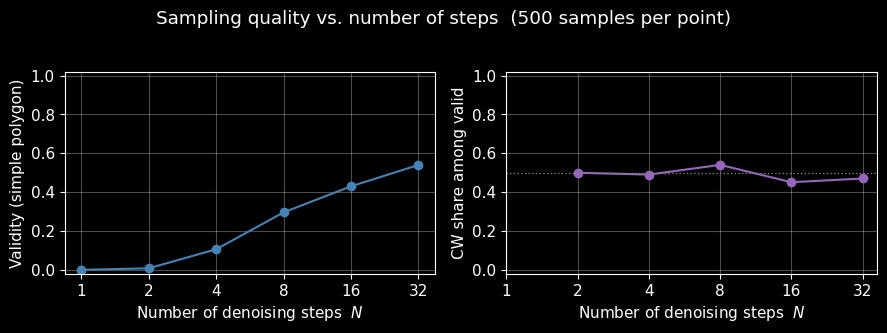

In [37]:
def evaluate_sampler(sampler_fn, key, n_samples=EVAL_N_SAMPLES, **kwargs):
    """Return (validity_rate, cw_fraction_among_valid, sampled_walks) for one sampler."""
    out, _ = sampler_fn(key, n_samples=n_samples, **kwargs)
    out = np.array(out)
    n_valid = n_cw = 0
    for s in out:
        ok, ch = is_simple_polygon(s)
        if ok:
            n_valid += 1
            if ch == 'CW':
                n_cw += 1
    cw_frac = n_cw / n_valid if n_valid else float('nan')
    return n_valid / len(out), cw_frac, out


def naive_sampler(sk, n_samples, n_steps):
    return sample(params_full, sk, n_samples=n_samples, n_steps=n_steps)


valid_rates, cw_fracs, samples_by_T = [], [], {}
for ns in STEPS_COMPARE:
    key, sk = random.split(key)
    v, c, walks = evaluate_sampler(naive_sampler, sk, n_steps=ns)
    valid_rates.append(v); cw_fracs.append(c); samples_by_T[ns] = walks
    print(f'N = {ns:>3d}   valid = {v:.1%}   CW share among valid = {c:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].plot(STEPS_COMPARE, valid_rates, 'o-', color='steelblue')
axes[0].set_xscale('log', base=2); axes[0].set_xticks(STEPS_COMPARE)
axes[0].get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
axes[0].set_xlabel('Number of denoising steps  $N$')
axes[0].set_ylabel('Validity (simple polygon)')
axes[0].set_ylim(-0.02, 1.02); axes[0].grid(True, alpha=0.3)
axes[1].plot(STEPS_COMPARE, cw_fracs, 'o-', color='tab:purple')
axes[1].axhline(0.5, color='grey', ls=':', lw=1)
axes[1].set_xscale('log', base=2);
axes[1].set_xticks(STEPS_COMPARE)
axes[1].get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
axes[1].set_xlabel('Number of denoising steps  $N$')
axes[1].set_ylabel('CW share among valid')
axes[1].set_ylim(-0.02, 1.02); axes[1].grid(True, alpha=0.3)
plt.suptitle(f'Sampling quality vs. number of steps  ({EVAL_N_SAMPLES} samples per point)', y=1.03)
plt.tight_layout(); plt.show()


## Improving Sampling with Confidence Sampling

A method to improving on the step-count trade-off:

- **Confidence remasking** — at each step, unmask only the $\lceil L/N \rceil$ most-confident still-masked positions (where the probability for the sampled token was highest).

It does not introduce extra compute (same number of forward passes).

  naive       valid = 29.2%   CW share = 44.5%
  confidence  valid = 56.8%   CW share = 75.4%


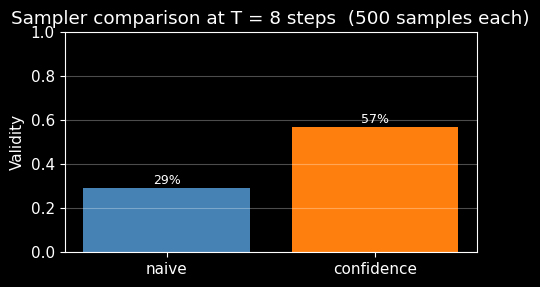

In [42]:
def sample_confidence(params, key, n_samples, n_steps):
    """MaskGit-style confidence remasking.
    At each step: predict everywhere, then keep only the top-K most-confident positions;
    the rest are re-masked. K rises by L/N each step until all positions are committed.
    """
    x_t = jnp.full((n_samples, L), MASK, dtype=jnp.int32)
    B   = n_samples
    batch_idx = jnp.arange(B)[:, None]
    pos_idx   = jnp.arange(L)[None, :]

    for k in range(n_steps):
        target_unmasked = int(np.ceil(L * (k + 1) / n_steps))
        key, k1 = random.split(key)
        logits  = predict_logits(params, x_t)
        probs   = jax.nn.softmax(logits, axis=-1)
        sampled = random.categorical(k1, logits, axis=-1)
        is_mask = (x_t == MASK)
        tentative = jnp.where(is_mask, sampled, x_t)
        sample_prob = probs[batch_idx, pos_idx, sampled]
        conf = jnp.where(is_mask, sample_prob, 1.0)
        sorted_desc = -jnp.sort(-conf, axis=-1)
        threshold = sorted_desc[:, target_unmasked - 1][:, None]
        keep = conf >= threshold
        x_t = jnp.where(keep, tentative, MASK)
    return x_t, None


# Compare the two samplers at a fixed step budget where naive struggles
T_COMPARE = 8
samplers = {
    'naive':      lambda sk, n_samples, **kw: sample(params_full, sk, n_samples=n_samples, n_steps=T_COMPARE),
    'confidence': lambda sk, n_samples, **kw: sample_confidence(params_full, sk, n_samples=n_samples, n_steps=T_COMPARE),
}
results = {}
for name, fn in samplers.items():
    key, sk = random.split(key)
    results[name] = evaluate_sampler(fn, sk)
for name, (v, c, _) in results.items():
    print(f'  {name:10s}  valid = {v:.1%}   CW share = {c:.1%}')

fig, ax = plt.subplots(figsize=(5, 3))
names  = list(results.keys())
values = [results[n][0] for n in names]
bars = ax.bar(names, values, color=['steelblue', 'tab:orange'])
ax.set_ylabel('Validity'); ax.set_ylim(0, 1)
ax.set_title(f'Sampler comparison at T = {T_COMPARE} steps  ({EVAL_N_SAMPLES} samples each)')
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.0%}',
            ha='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

## MDLM vs. DDPM vs. Flow Matching

| | **DDPM** | **Flow Matching (CFM)**                                        | **MDLM** |
|---|---|----------------------------------------------------------------|---|
| **State space** | continuous | continuous                                                     | discrete |
| **Forward process** | add Gaussian noise | deterministic linear interpolation (between noise and samples) | mask each position with prob $t$ |
| **Network target** | noise $\varepsilon$ | velocity $x_1 - x_0$                                           | original token $x_0[i]$ at masked positions |
| **Loss** | MSE | MSE                                                            | weighted CE (ELBO) |
| **Sampling** | stochastic reverse chain, 100–1000 steps | ODE integration, 10–50 steps                                   | iterative unmasking, 5–50 steps |
| **Per-step update** | all dims | all dims                                                       | all masked positions, in parallel |

All three are **probability path models**: they specify a family of distributions $p_t$ interpolating between $p_\text{data}$ and a reference distribution (Gaussian / noise / all-MASK), and learn a conditional quantity that enables traversal of the path. The choice of path (Gaussian mixing, linear interpolation, Bernoulli erasure) is what differs.

## Extensions to Explore

- **Discrete Diffusion via Score Entropy (SEDD)**: for absorbing noise, MDLM's weighted CE is equivalent to SEDD's score entropy. SEDD generalises to *uniform* noise (any token flips to any other) and structured Markov generators, at the cost of a more complex loss. See [Discrete Diffusion blog post](https://aaronlou.com/blog/2024/discrete-diffusion/) or [Lou et al. (2023)](https://arxiv.org/abs/2310.16834).
- **Discrete flow matching** ([Gat et al., 2024](https://arxiv.org/abs/2407.15595); [Campbell et al., 2024](https://arxiv.org/abs/2402.04997)): reframes discrete diffusion as one choice of *probability path* in a broader flow-matching framework. Other paths (e.g. uniform interpolation) become available.
- **Large-scale dLLMs**: [LLaDA-8B](https://arxiv.org/abs/2502.09992), Gemini Diffusion, deployed or research-grade diffusion LMs are MDLM or close variants.
- **Remasking / non-monotonic sampling**: allowing already-revealed tokens to be re-masked can improve quality; typical in production dLLMs.